In [ ]:
#numerical method programming for finding the max rate of climb.
"idea: use root finding algorithm to find the equilibrium point. i.e the intersection of the two forces， python has a build in function for numerical method called scipy.optimize.brentq"
"which also finds the numerical solution."
#for simplicity and less conputation, we can use the bisection method. 
# we just have make sure the starting point is not the origin

thro = 0.1
T_0 = 147500
rho_0 = 1.225
lc = 0.5  # lift coefficient



wing_area = 10.0  # wing area in m^2
dc_0 = 0.02  # zero lift drag coefficient
k = 0.1  # induced drag factor
dc = k * lc**2 + dc_0  # total drag coefficient

#note that the information on bisection method can be found separately in any youtube videos or books related to numerical methods. It is one of the simplest root finding techniques.
def bisection_method(f, a, b, eps= 1e-5, max_iter=1000):
    d = f(a)*f(b)
    # the initial condition
    if d>= 0:
        raise ValueError("Function must have opposite signs at the interval endpoints.")

    c = a

    for i in range(max_iter):
    
        c = (a + b) / 2.0
        
        if abs(f(c)) < eps:
            return c
        
    
        if f(a) * f(c) < 0:
            b = c
        else:
            a = c

  
    raise ValueError("Maximum number of iterations reached without finding a root.")

def f(x):
    return 0.5 * rho_0 * x**2 * wing_area * dc -T_0* thro # the function to find the root of.


#the interval
a = 200
b = 250

root = bisection_method(f, a, b)
print(f"root: {root}")


root: 231.33252952247858


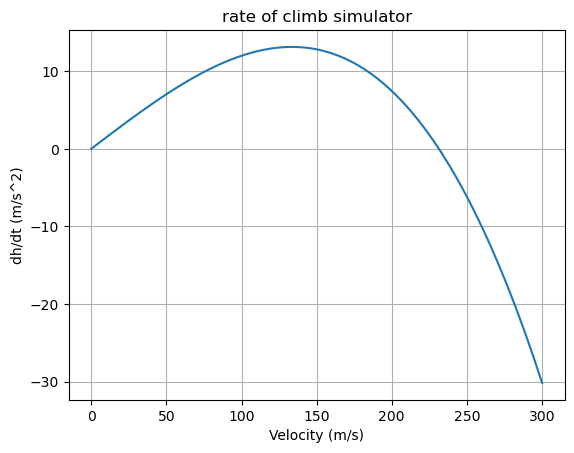

In [ ]:
#vertical motion of the aircraft

"the basis of this model is to use P = F*v, the climb rate is therefore the vertical component of the force divided by the weight"
#dh/dt = (Thrust-Drag) * velocity / Weight

#carrying on from the previous model. we have f(v)v = P(excess)
weight = 100000 #controlled weight here in N

def rateofclimb(v):
    return -(0.5 * rho_0 * v**2 * wing_area * dc -T_0* thro)*v/weight

import matplotlib.pyplot as plt
import numpy as np
velocity = np.linspace(0, 300, 100)
climb_rates = rateofclimb(velocity)
plt.plot(velocity, climb_rates)
plt.xlabel('Velocity (m/s)')
plt.ylabel('dh/dt (m/s)')
plt.title('rate of climb simulator')
plt.grid(True)
plt.show()
#based on the plot the maximum rate of climb appears to be around 13m/s at around 130 m/s velocity